# 04. Baselines and ARIMA

Notebook 03 established two things: NFLX prices contain a unit root, and returns show no usable
autocorrelation. Together those imply the naive forecast, tomorrow equals today, is close to
optimal.

This notebook builds the models that test that claim, and locks the results table that every
later model has to beat.

Nothing here is complicated. That is deliberate. If a neural network cannot outperform four lines
of arithmetic, the neural network has not earned its complexity, and the only way to know is to
compute the arithmetic first.

## Setup and splits

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, plots, evaluate as ev
from src.data import load_prices
from src.models import baselines as bl, arima

plots.use_project_style()

nflx = load_prices(config.TICKER).iloc[:-1]
close = nflx["Close"]

n = len(close)
train_sl, val_sl, test_sl = ev.chronological_split(
    n, config.TRAIN_FRAC, config.VAL_FRAC
)
val_idx = np.arange(val_sl.start, val_sl.stop)
test_idx = np.arange(test_sl.start, test_sl.stop)

actual = close.values[test_idx]
previous = close.values[test_idx - 1]
n_test = len(test_idx)

for label, sl in [("train", train_sl), ("validation", val_sl), ("test", test_sl)]:
    print(f"{label:>11}: {sl.stop - sl.start:>5} days   "
          f"{close.index[sl.start].date()} to {close.index[sl.stop - 1].date()}")

      train:  2055 days   2015-01-02 to 2023-03-02
 validation:   440 days   2023-03-03 to 2024-11-29
       test:   441 days   2024-12-02 to 2026-09-04


### Why the split is chronological and never shuffled

Shuffling is standard practice almost everywhere in machine learning and is catastrophic here. A
shuffled split puts future days in the training set and past days in the test set, so the model
learns from tomorrow and is graded on yesterday. The scores come out excellent and mean nothing.

Time ordered splits are the only defensible choice for forecasting, and the test set has to be
the most recent block.

saved -> reports/figures/04_splits.png


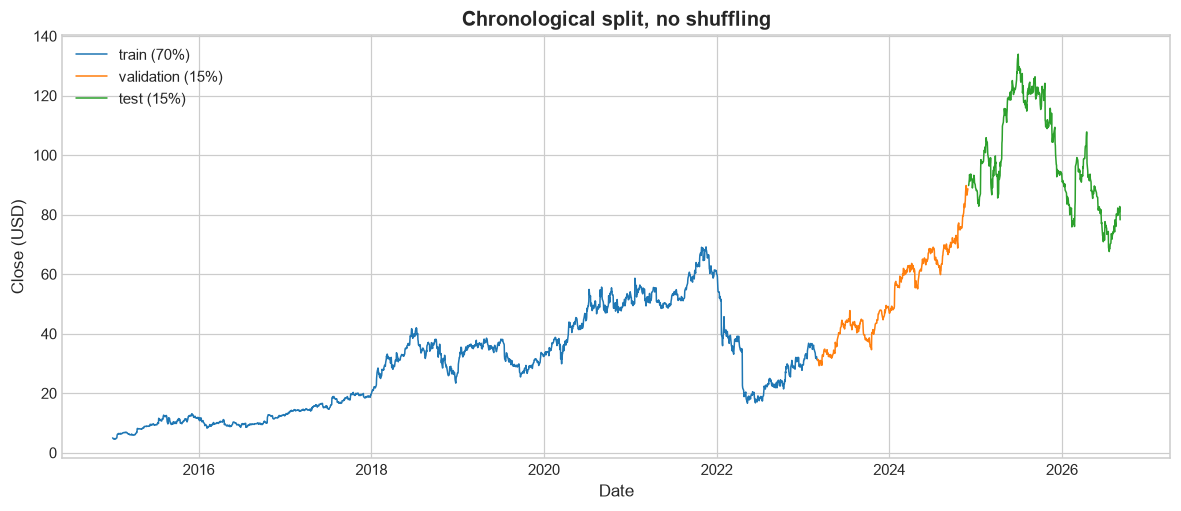

In [2]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(close.index[train_sl], close.values[train_sl], linewidth=1.0, label="train (70%)")
ax.plot(close.index[val_sl], close.values[val_sl], linewidth=1.0, label="validation (15%)")
ax.plot(close.index[test_sl], close.values[test_sl], linewidth=1.0, label="test (15%)")
ax.set_title("Chronological split, no shuffling")
ax.set_ylabel("Close (USD)")
ax.set_xlabel("Date")
ax.legend()

plots.save(fig, "04_splits")
plt.show()

Note the test period covers the largest drawdown in the series. That is not a convenient sample,
and it is exactly why it should not be cherry picked away. A model that only works in calm markets
is not a model.

---
## 1. The baselines

Four forecasts, each using only information available the day before:

| Model | Rule |
|---|---|
| Naive (persistence) | tomorrow equals today |
| Drift | today plus the average daily change measured on training data |
| SMA(k) | average of the last k closes |
| EMA(k) | exponentially weighted average, recent days weighted more |

The drift term is computed on the **training set only**. Measuring it over the whole series would
be using the future to forecast the future.

### Tuning the window on validation, never on test

SMA and EMA each have one parameter. Choosing it by test performance would be fitting to the data
we are about to be scored on, so the choice is made on the validation block.

In [3]:
best_sma, sma_table = bl.tune_window(close, val_idx, bl.sma)
best_ema, ema_table = bl.tune_window(close, val_idx, bl.ema)

print(f"SMA: best window {best_sma}")
print(sma_table.to_string(index=False))
print(f"\nEMA: best span {best_ema}")
print(ema_table.to_string(index=False))

SMA: best window 2
 parameter  val_RMSE
         2    1.2176
         3    1.3506
         5    1.5947
        10    2.1463
        20    3.0298
        50    4.7164

EMA: best span 2
 parameter  val_RMSE
         2    1.1465
         3    1.2483
         5    1.4565
        10    1.9264
        20    2.6722
        50    4.2147


### The tuning result is itself a finding

Validation error increases monotonically with window length. The shortest window available wins,
and it would keep winning if shorter ones existed.

That is the optimiser telling us something: averaging over history actively destroys information
here. The best moving average is the one that averages least, and its limit as the window shrinks
to one day **is the naive forecast**. Two independent lines of evidence now point the same way,
the unit root test in notebook 03 and this tuning curve.

---
## 2. ARIMA

Notebook 03 read no clear structure off the ACF and PACF, so rather than assume an order we fit a
small grid and let AIC choose. AIC balances fit against parameter count, penalising models that
buy a marginally better fit with extra complexity.

In [4]:
orders = [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 2), (5, 1, 0)]
grid = arima.fit_grid(close.iloc[: val_sl.stop], orders)
grid

,order,AIC,BIC,converged
0,"(0, 1, 0)",6732.29,6738.11,True
1,"(1, 1, 0)",6733.50,6745.14,True
2,"(0, 1, 1)",6733.51,6745.15,True
3,"(2, 1, 2)",6733.92,6763.02,False
4,"(1, 1, 1)",6735.39,6752.85,True
5,"(5, 1, 0)",6736.38,6771.31,True


**AIC selects ARIMA(0,1,0).**

Worth unpacking, because it is the cleanest result in the project. ARIMA(0,1,0) has no
autoregressive terms and no moving average terms. It is:

$$P_t = P_{t-1} + \varepsilon_t$$

which is a random walk, which is the naive forecast. Given a menu of models that includes several
with real parameters, the information criterion picks the one with none.

The classical model selection machinery, applied honestly, concludes there is nothing to model.

### Rolling one step ahead forecasting

The test forecast is generated one day at a time. After each prediction the true observation is
appended to the model's history before the next prediction is made, so the model always knows
everything up to yesterday and nothing about tomorrow.

Forecasting all 441 test days in a single call would be a different and much easier question to
fail at, since errors would compound and the comparison to the baselines would not be like for
like.

In [5]:
arima_preds = {}
for order in [(0, 1, 0), (1, 1, 1)]:
    arima_preds[order] = arima.rolling_forecast(close, order, n_test)
    print(f"ARIMA{order}: {n_test} one step ahead forecasts generated")

ARIMA(0, 1, 0): 441 one step ahead forecasts generated


ARIMA(1, 1, 1): 441 one step ahead forecasts generated


---
## 3. The results table

Every model, one test set, identical splits.

In [6]:
rows = [
    ev.evaluate("Naive (persistence)", actual, bl.naive(close, test_idx), previous),
    ev.evaluate("Drift", actual, bl.drift(close, test_idx, train_sl.stop), previous),
    ev.evaluate(f"SMA({best_sma})", actual, bl.sma(close, test_idx, best_sma), previous),
    ev.evaluate(f"EMA({best_ema})", actual, bl.ema(close, test_idx, best_ema), previous),
]
for order, pred in arima_preds.items():
    rows.append(ev.evaluate(f"ARIMA{order}", actual, pred, previous))

results = ev.results_table(rows)
results

,RMSE,MAE,MAPE %,Directional %,RMSE on returns
model,,,,,
Naive (persistence),2.1295,1.4774,1.519,NaN,0.021964
Drift,2.1297,1.4776,1.519,49.31,0.021964
SMA(2),2.3957,1.6988,1.743,48.17,0.024789
EMA(2),2.2831,1.6070,1.647,50.57,0.023613
"ARIMA(0, 1, 0)",2.1295,1.4774,1.519,NaN,0.021964
"ARIMA(1, 1, 1)",2.1303,1.4790,1.520,50.60,0.021976


### Reading the table

**The naive forecast wins on RMSE.** Nothing beats it. ARIMA(0,1,0) ties it exactly, because they
are the same model expressed two different ways.

**Drift adds nothing.** The extra term changes RMSE in the fourth decimal place. Ten years of
upward drift amounts to a few cents a day, which is invisible against daily volatility of about
2.7 percent.

**Both moving averages are worse than doing nothing.** Smoothing introduces lag, and lag costs
more than the noise it removes.

**Directional accuracy sits at a coin flip.** Every model that takes a position lands between 48
and 51 percent. None of them can tell up from down.

Naive and ARIMA(0,1,0) show NaN because they never take a directional position at all. They
predict no change. That is not a failure to score, it is an honest blank: a model that declines to
make a directional claim cannot be graded on directional accuracy, and reporting a number there
would be inventing one.

---
## 4. Seeing the lag

Every one of these models produces a chart that looks impressive from a distance. The zoom is
where the illusion breaks.

saved -> reports/figures/04_predictions_and_lag.png


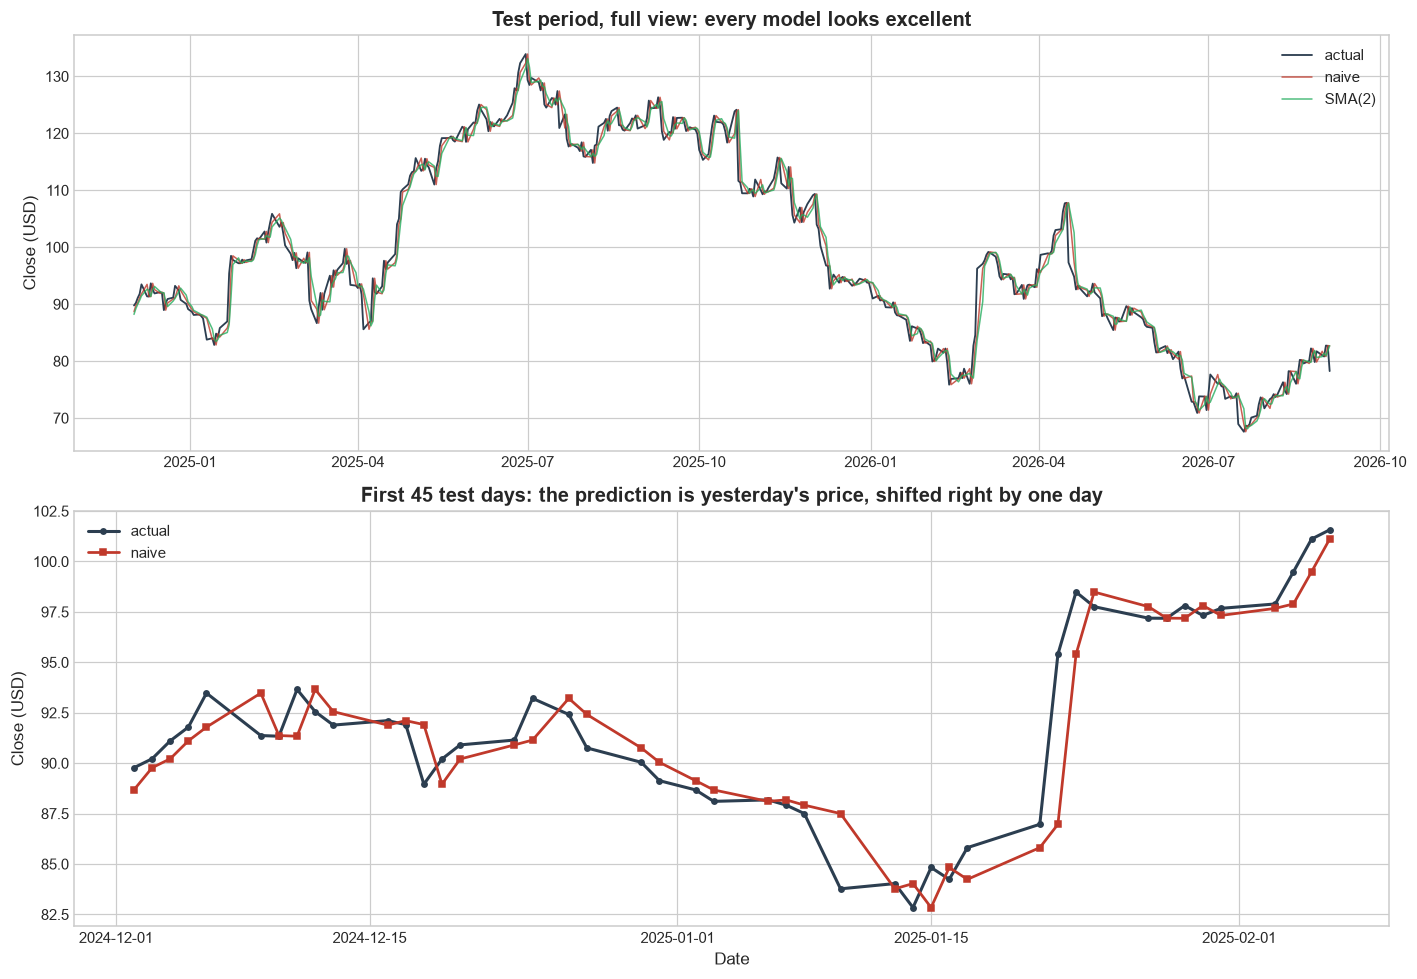

In [7]:
dates = close.index[test_idx]
naive_pred = bl.naive(close, test_idx)
sma_pred = bl.sma(close, test_idx, best_sma)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

axes[0].plot(dates, actual, linewidth=1.2, label="actual", color="#2c3e50")
axes[0].plot(dates, naive_pred, linewidth=1.0, alpha=0.8, label="naive", color="#c0392b")
axes[0].plot(dates, sma_pred, linewidth=1.0, alpha=0.8, label=f"SMA({best_sma})", color="#27ae60")
axes[0].set_title("Test period, full view: every model looks excellent")
axes[0].set_ylabel("Close (USD)")
axes[0].legend()

zoom = slice(0, 45)
axes[1].plot(dates[zoom], actual[zoom], linewidth=2.0, marker="o", markersize=3.5,
             label="actual", color="#2c3e50")
axes[1].plot(dates[zoom], naive_pred[zoom], linewidth=1.8, marker="s", markersize=3.5,
             label="naive", color="#c0392b")
axes[1].set_title("First 45 test days: the prediction is yesterday's price, shifted right by one day")
axes[1].set_ylabel("Close (USD)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plots.save(fig, "04_predictions_and_lag")
plt.show()

The bottom panel is the point of this notebook. The red line is not tracking the black line, it is
**copying it one day late**. Zoomed out, that shift is invisible and the fit looks superb. Zoomed
in, there is no prediction happening at all.

This is the diagnostic to apply to the LSTM in notebook 05.

### Quantifying the lag

Rather than argue from a picture, measure where the prediction best correlates with the actual
series.

In [8]:
lag_tab = ev.lag_correlation(actual, naive_pred, max_lag=4)
print("Naive forecast:")
print(lag_tab.to_string(index=False))

Naive forecast:
 lag_days  correlation
        0     0.991719
        1     0.983210
        2     0.974090
        3     0.964530
        4     0.954302


Correlation peaks at lag 0 by construction here, since the naive prediction *is* the previous
actual value and both series share the same trend. The number to watch in notebook 05 is whether
the LSTM behaves any differently, or whether it reproduces this same profile after training for
several minutes on a GPU.

---
## 5. Save the results

In [9]:
config.ensure_dirs()
out = config.DATA_PROCESSED / "results_baselines.csv"
results.to_csv(out)
print(f"saved -> data/processed/{out.name}")

np.save(config.DATA_PROCESSED / "test_actual.npy", actual)
np.save(config.DATA_PROCESSED / "test_previous.npy", previous)
np.save(config.DATA_PROCESSED / "test_naive.npy", naive_pred)
pd.Series(dates).to_csv(config.DATA_PROCESSED / "test_dates.csv", index=False)
print("saved test arrays for notebooks 05 and 06")

saved -> data/processed/results_baselines.csv
saved test arrays for notebooks 05 and 06


---
## What this established

1. **The naive forecast is the best model in this notebook.** Nothing beats it on RMSE, MAE or
   MAPE.
2. **AIC independently selected ARIMA(0,1,0)**, which is the random walk, which is the naive
   forecast. Classical model selection, given a real menu of alternatives, concluded there is
   nothing to model.
3. **Window tuning converges toward the naive forecast.** Validation error rises monotonically
   with window length, so the best average is the one that averages least.
4. **No model can tell up from down.** Directional accuracy is 48 to 51 percent against a 50
   percent coin flip.
5. **The lag diagnostic works.** Zoomed out, a lagged copy looks like an excellent forecast.
   Zoomed in, it is visibly one day behind.

The bar is now set. RMSE to beat: **2.1295**. Directional accuracy to beat: **50 percent**.

**Next:** `05_lstm.ipynb`, building the LSTM with train only scaling, early stopping and a
leakage test, then running it against this table.